In [7]:
import mdptoolbox.example
P, R = mdptoolbox.example.forest()
vi = mdptoolbox.mdp.ValueIteration(P, R, 0.9)
vi.run()
vi.policy # result is (0, 0, 0)

(0, 0, 0)

=== Value Iteration ===
Optimal Policy (VI): (0, 1, 0)
Optimal Value Function (VI): (27.138222319058606, 19.997677873859306, 0.0)

=== Policy Iteration ===
Optimal Policy (PI): (0, 1, 0)
Optimal Value Function (PI): (27.142857142857157, 20.000000000000007, 0.0)

Value Iteration history: not available in this mdptoolbox build.
Policy Iteration history: not available in this mdptoolbox build.


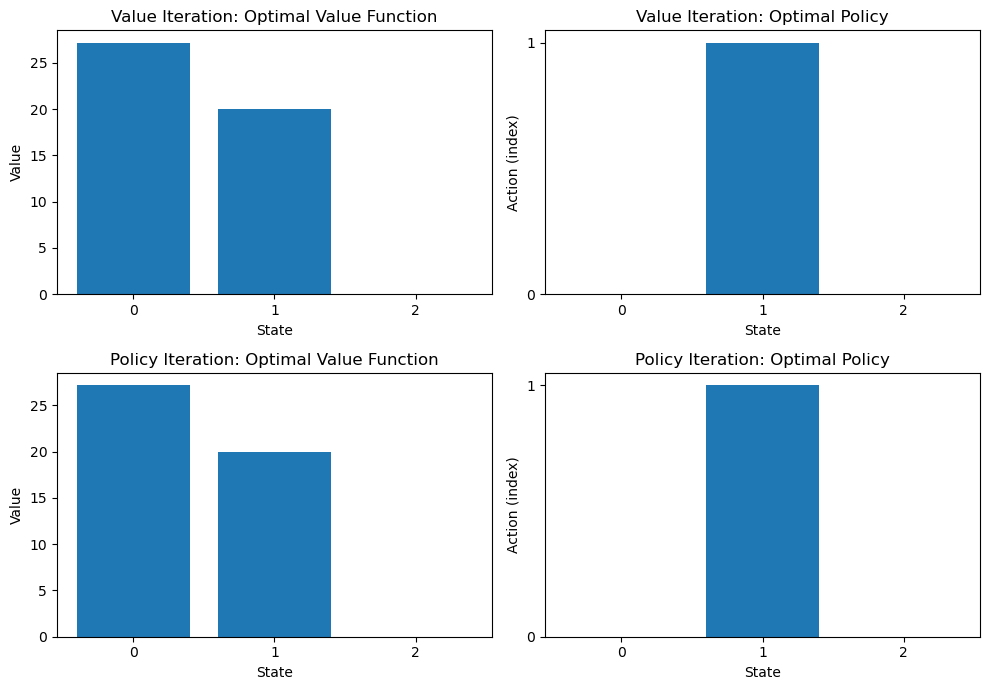


No convergence history available to plot (mdptoolbox version may not expose it).

Pretty policies:
VI policy: S0:A0, S1:A1, S2:A0
PI policy: S0:A0, S1:A1, S2:A0


In [6]:
import numpy as np
import mdptoolbox
import matplotlib.pyplot as plt

# -----------------------------
# Helper: safe history extractor
# -----------------------------
def extract_history(obj):
    """
    Try common attribute names that might contain convergence history.
    If found and iterable, return it as a list. Otherwise return None.
    """
    candidate_names = ('iterations', 'delta', 'history', 'residuals', 'deltas', 'changes')
    for name in candidate_names:
        if hasattr(obj, name):
            val = getattr(obj, name)
            # If it's a scalar integer/float, skip
            if isinstance(val, (int, float)):
                continue
            try:
                return list(val)
            except TypeError:
                continue
    return None

# -----------------------------
# Example MDP DEFINITION
# -----------------------------
n_states = 3
n_actions = 2

# Transition probability matrices: P[a][s][s']
P = np.zeros((n_actions, n_states, n_states))

P[0] = np.array([
    [0.8, 0.2, 0.0],
    [0.1, 0.7, 0.2],
    [0.0, 0.0, 1.0]
])

P[1] = np.array([
    [0.5, 0.5, 0.0],
    [0.0, 0.9, 0.1],
    [0.0, 0.0, 1.0]
])

# Reward matrices: R[a][s][s']
R = np.zeros((n_actions, n_states, n_states))

R[0] = np.array([
    [5, 0, 0],
    [0, 3, 1],
    [0, 0, 0]
])

R[1] = np.array([
    [2, 1, 0],
    [0, 4, 2],
    [0, 0, 0]
])

gamma = 0.9

# -----------------------------
# RUN VALUE ITERATION
# -----------------------------
vi = mdptoolbox.mdp.ValueIteration(P, R, gamma)
vi.run()

print("=== Value Iteration ===")
print("Optimal Policy (VI):", vi.policy)
print("Optimal Value Function (VI):", vi.V)

# -----------------------------
# RUN POLICY ITERATION
# -----------------------------
pi = mdptoolbox.mdp.PolicyIteration(P, R, gamma)
pi.run()

print("\n=== Policy Iteration ===")
print("Optimal Policy (PI):", pi.policy)
print("Optimal Value Function (PI):", pi.V)

# -----------------------------
# EXTRACT CONVERGENCE HISTORY IF AVAILABLE
# -----------------------------
vi_hist = extract_history(vi)
pi_hist = extract_history(pi)

if vi_hist is not None:
    print("\nValue Iteration history length:", len(vi_hist))
else:
    print("\nValue Iteration history: not available in this mdptoolbox build.")

if pi_hist is not None:
    print("Policy Iteration history length:", len(pi_hist))
else:
    print("Policy Iteration history: not available in this mdptoolbox build.")

# -----------------------------
# VISUALIZATION
# -----------------------------
states = np.arange(n_states)
actions = np.arange(n_actions)

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.ravel()

# VI: value function
axes[0].bar(states, vi.V)
axes[0].set_xlabel("State")
axes[0].set_ylabel("Value")
axes[0].set_title("Value Iteration: Optimal Value Function")
axes[0].set_xticks(states)

# VI: policy
axes[1].bar(states, vi.policy)
axes[1].set_xlabel("State")
axes[1].set_ylabel("Action (index)")
axes[1].set_title("Value Iteration: Optimal Policy")
axes[1].set_yticks(actions)
axes[1].set_xticks(states)

# PI: value function
axes[2].bar(states, pi.V)
axes[2].set_xlabel("State")
axes[2].set_ylabel("Value")
axes[2].set_title("Policy Iteration: Optimal Value Function")
axes[2].set_xticks(states)

# PI: policy
axes[3].bar(states, pi.policy)
axes[3].set_xlabel("State")
axes[3].set_ylabel("Action (index)")
axes[3].set_title("Policy Iteration: Optimal Policy")
axes[3].set_yticks(actions)
axes[3].set_xticks(states)

plt.tight_layout()
plt.show()

# If either algorithm provides a convergence/history vector, plot them separately
if vi_hist is not None or pi_hist is not None:
    plt.figure(figsize=(6,4))
    if vi_hist is not None:
        plt.plot(vi_hist, label='Value Iteration')
    if pi_hist is not None:
        plt.plot(pi_hist, label='Policy Iteration')
    plt.xlabel('Iteration')
    plt.ylabel('Max change / Residual (algorithm-specific)')
    plt.title('Convergence History (if available)')
    plt.legend()
    plt.yscale('log')  # often useful to show convergence on log scale
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()
else:
    print("\nNo convergence history available to plot (mdptoolbox version may not expose it).")

# -----------------------------
# OPTIONAL: Quick policy->text pretty print
# -----------------------------
def pretty_policy(policy_array):
    return ", ".join(f"S{idx}:A{int(a)}" for idx, a in enumerate(policy_array))

print("\nPretty policies:")
print("VI policy:", pretty_policy(vi.policy))
print("PI policy:", pretty_policy(pi.policy))
